# Loan Approval Prediction using Decision Tree and Random Forest

## 1. Project Overview
This project aims to predict whether a loan application will be **Approved** or **Rejected** using machine learning classification models.

Two popular tree-based models are used in this project:

- **Decision Tree Classifier**
- **Random Forest Classifier**

The dataset contains applicant-related financial and demographic information such as income, loan amount, CIBIL score, assets, education, and employment status.

This project covers:
- Data loading
- Data cleaning
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Model building
- Model evaluation
- Model comparison
- Feature importance analysis

The final goal is to identify which model performs better for loan approval prediction.

## 2. Import Libraries

In [2]:
# ==============================
#   Import Required Libraries
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

## 3. Load dataset

In [3]:
# ==============================
#   Load the Dataset
# ==============================

df = pd.read_csv("D:/DSML/Loan-Approval-Prediction-Decision-Tree-Random-Forest/data/loan_approval_dataset.csv")

# Display first 5 rows
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 4. Basic Data Inspection

In [4]:
# ==============================
#    Basic Data Inspection
# ==============================

print("Shape of the dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape of the dataset: (4269, 13)

Column names:
['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [6]:
# Check missing values
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [7]:
# Statistical summary
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## 5. Data Cleaning

In [8]:
# ==============================
#    Data Cleaning
# ==============================

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check updated column names
df.columns.tolist()

['loan_id',
 'no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

In [9]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
# Check unique values in categorical columns
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].unique())


Unique values in 'education':
[' Graduate' ' Not Graduate']

Unique values in 'self_employed':
[' No' ' Yes']

Unique values in 'loan_status':
[' Approved' ' Rejected']


In [11]:
# Remove leading/trailing spaces from categorical values
for col in categorical_cols:
    df[col] = df[col].str.strip()

# Check again
for col in categorical_cols:
    print(f"\nCleaned unique values in '{col}':")
    print(df[col].unique())


Cleaned unique values in 'education':
['Graduate' 'Not Graduate']

Cleaned unique values in 'self_employed':
['No' 'Yes']

Cleaned unique values in 'loan_status':
['Approved' 'Rejected']


## 6. Exploratory Data Analysis
In this section, we explore the dataset to understand the distribution of the target variable and relationships among features.

### Target Variable Distribution

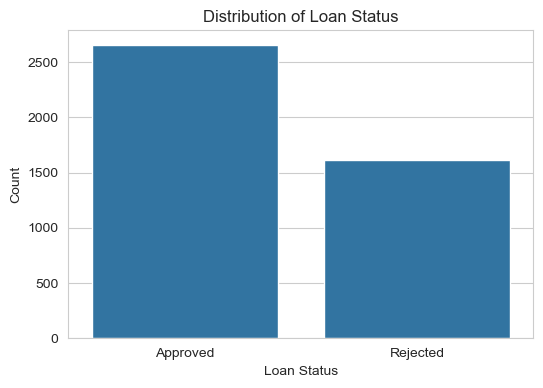

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [12]:
# ==============================
#    Exploratory Data Analysis
# ==============================

plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df)
plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.savefig("D:/DSML/Loan-Approval-Prediction-Decision-Tree-Random-Forest/images/loan_status_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(df['loan_status'].value_counts())

### Categorical Feature Analysis

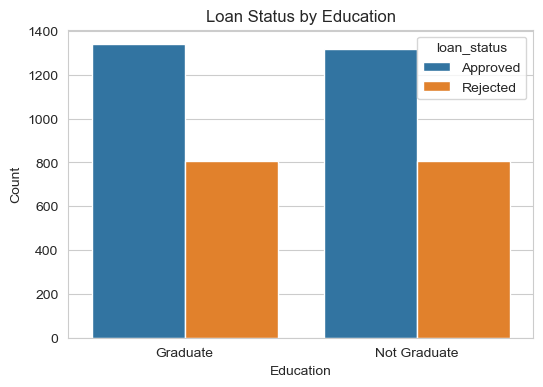

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x='education', hue='loan_status', data=df)
plt.title("Loan Status by Education")
plt.xlabel("Education")
plt.ylabel("Count")

plt.savefig("D:/DSML/Loan-Approval-Prediction-Decision-Tree-Random-Forest/images/loan_status_by_education.png", dpi=300, bbox_inches="tight")
plt.show()

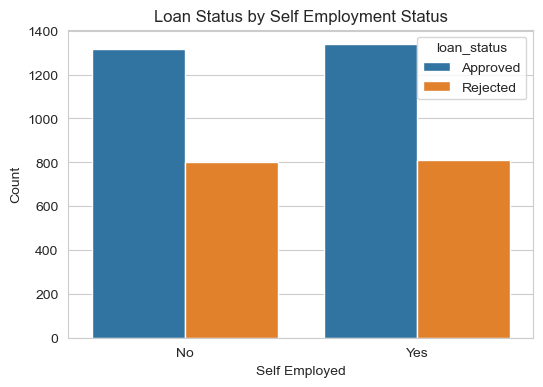

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x='self_employed', hue='loan_status', data=df)
plt.title("Loan Status by Self Employment Status")
plt.xlabel("Self Employed")
plt.ylabel("Count")

plt.savefig("D:/DSML/Loan-Approval-Prediction-Decision-Tree-Random-Forest/images/loan_status_by_self_employment.png", dpi=300, bbox_inches="tight")
plt.show()

### Numerical Feature Distributions

In [15]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols

['loan_id',
 'no_of_dependents',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value']

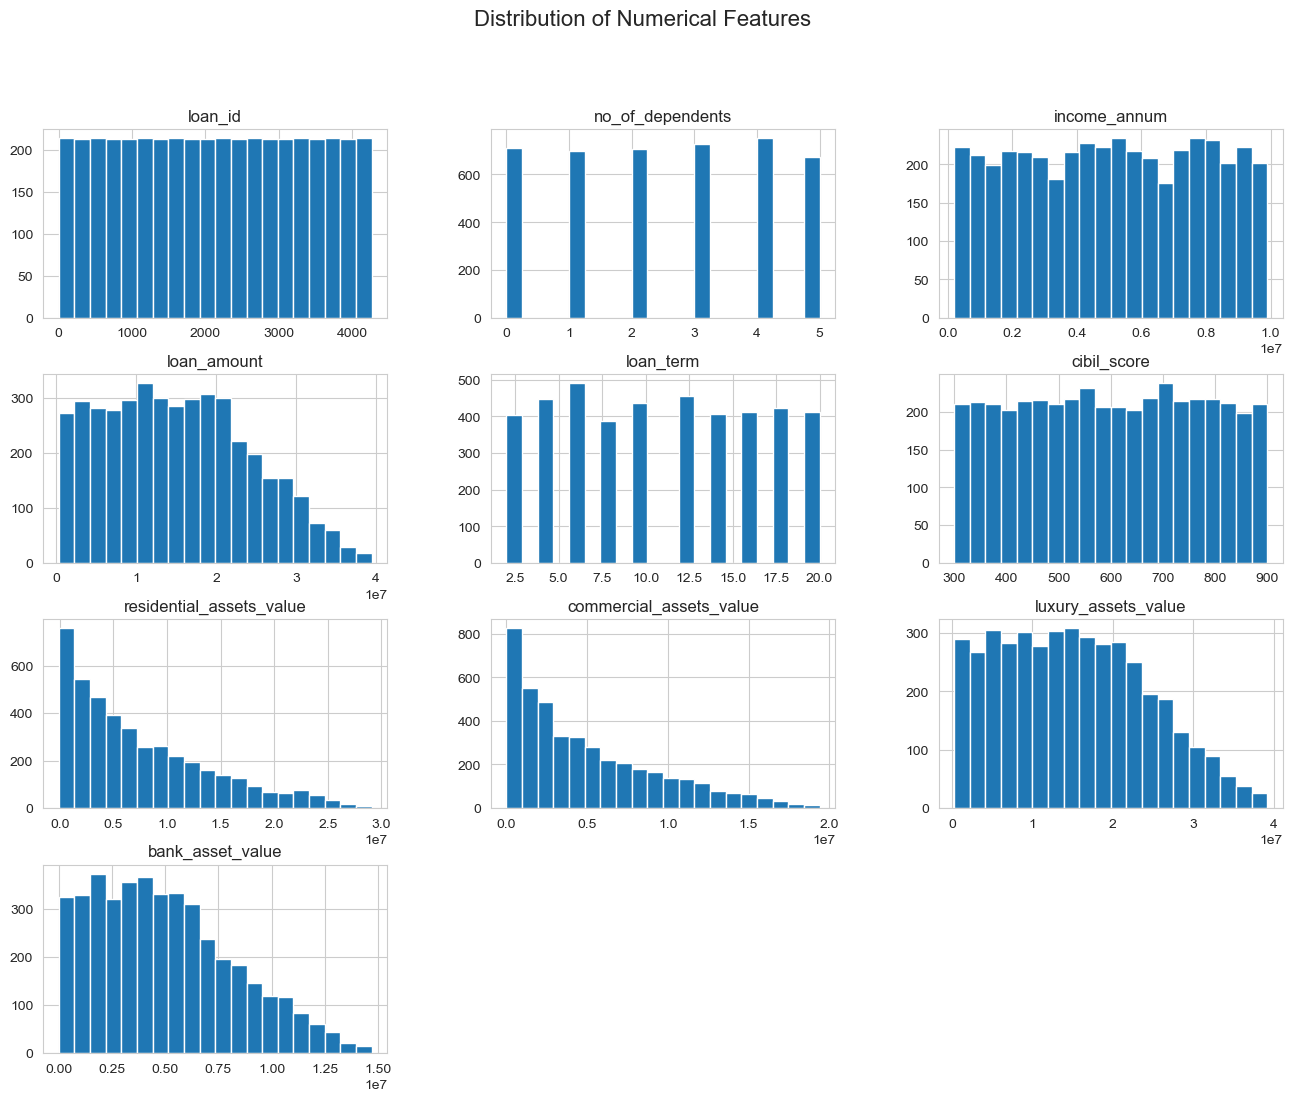

In [16]:
df[numerical_cols].hist(figsize=(16, 12), bins=20)
plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.savefig("D:/DSML/Loan-Approval-Prediction-Decision-Tree-Random-Forest/images/distribution_of_numerical_features.png", dpi=300, bbox_inches="tight")
plt.show()

### Correlation Heatmap

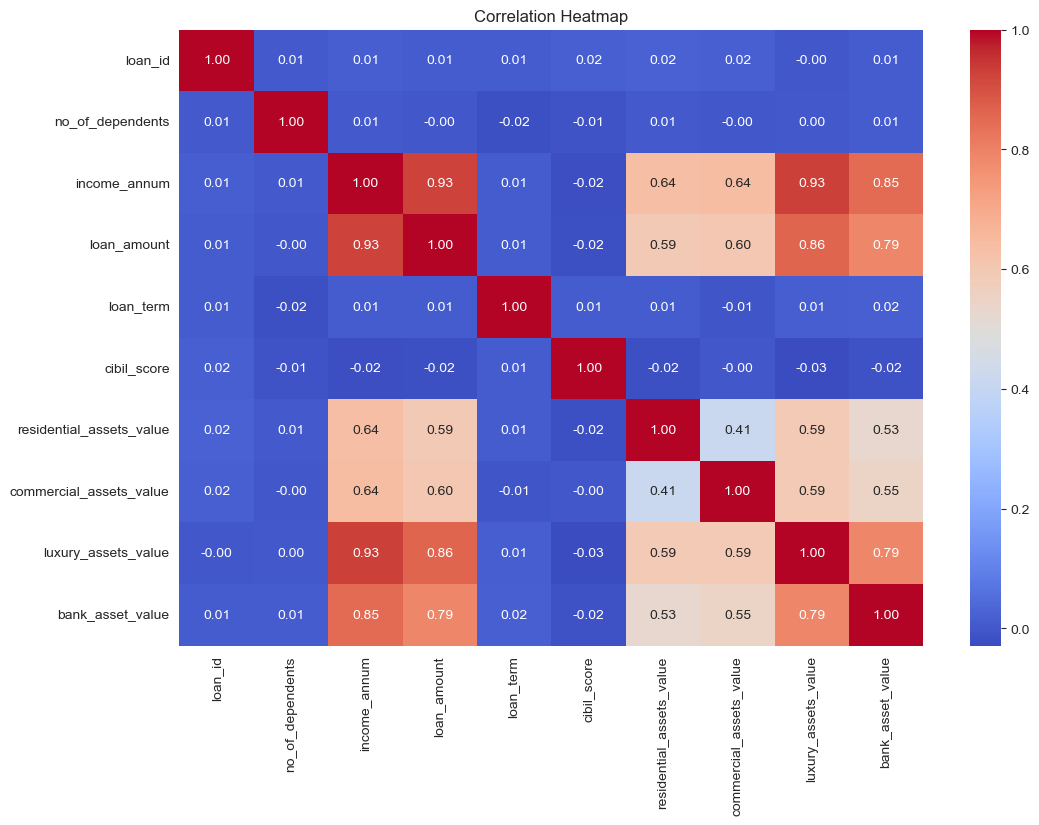

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")

plt.savefig("D:/DSML/Loan-Approval-Prediction-Decision-Tree-Random-Forest/images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Boxplots of Important Numerical Features

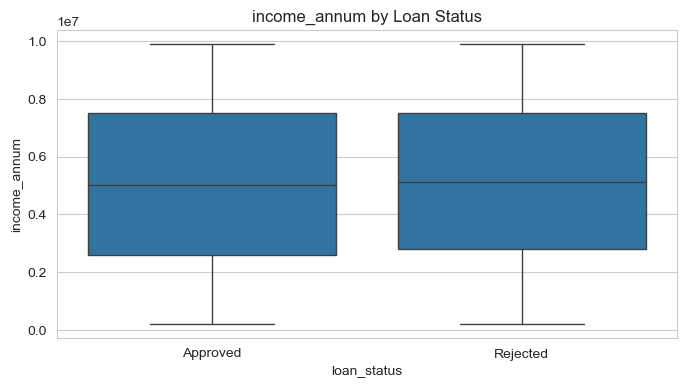

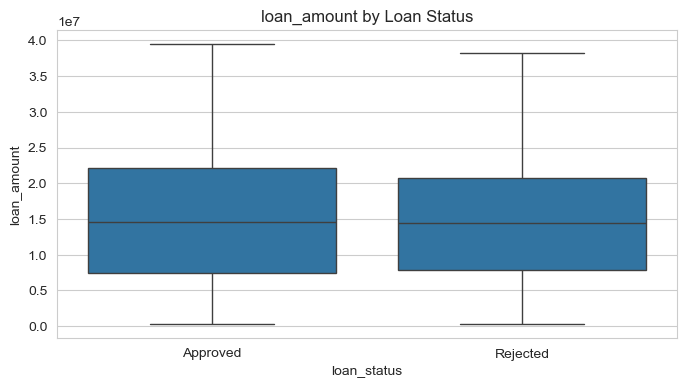

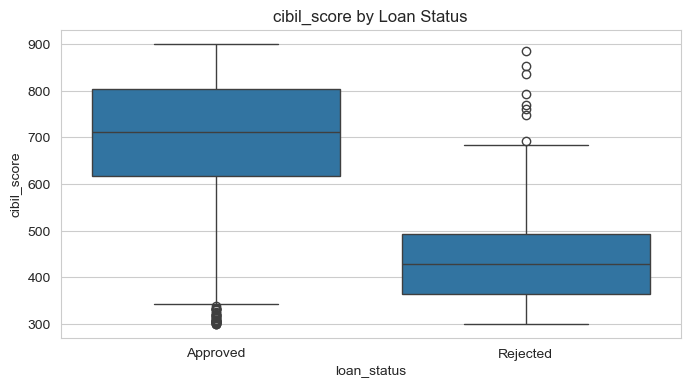

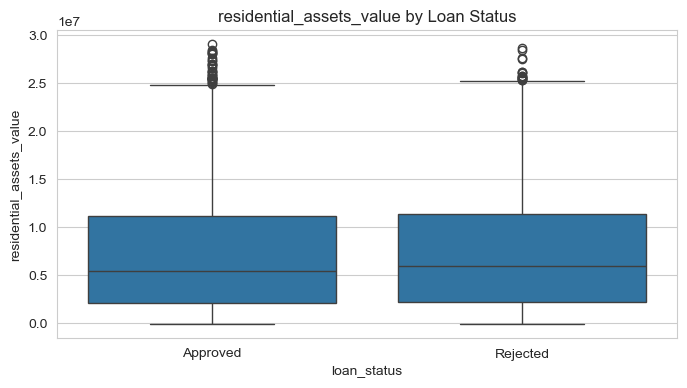

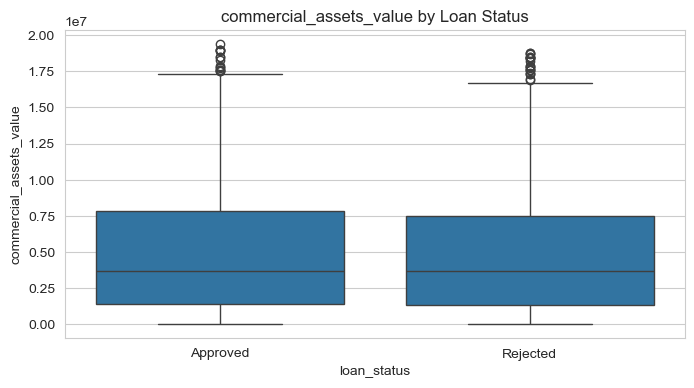

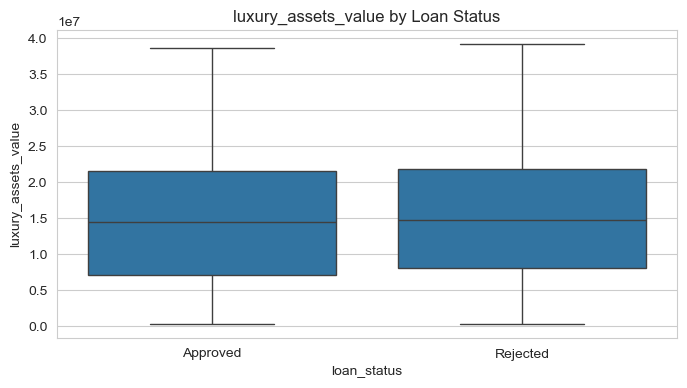

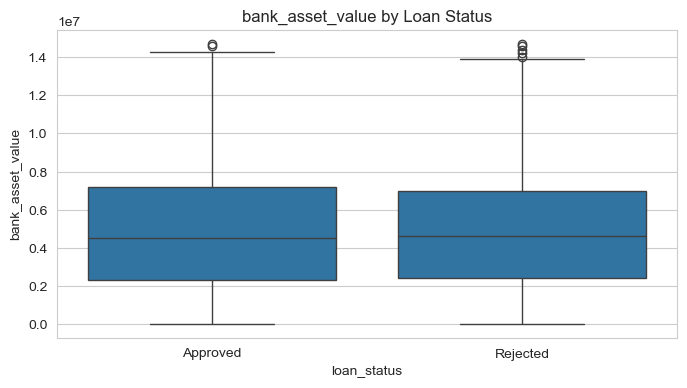

In [19]:
important_features = [
    'income_annum',
    'loan_amount',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

for col in important_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='loan_status', y=col, data=df)
    plt.title(f"{col} by Loan Status")

    plt.savefig(f"D:/DSML/Loan-Approval-Prediction-Decision-Tree-Random-Forest/images/{col}_by_loan_status_boxplot.png", dpi=300, bbox_inches='tight')
    plt.show()

## 7. Feature Selection and Preprocessing

### Data Preprocessing
Before training machine learning models, we prepare the dataset by:
- removing unnecessary columns
- encoding categorical variables
- separating features and target

In [20]:
# ==============================
#   Feature Selection
# ==============================

# Drop loan_id because it is only an identifier
df_model = df.drop('loan_id', axis=1)

df_model.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [21]:
# Encode categorical input features
le_education = LabelEncoder()
le_self_employed = LabelEncoder()
le_target = LabelEncoder()

df_model['education'] = le_education.fit_transform(df_model['education'])
df_model['self_employed'] = le_self_employed.fit_transform(df_model['self_employed'])
df_model['loan_status'] = le_target.fit_transform(df_model['loan_status'])

df_model.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [22]:
# Check encoded target mapping
print("Target classes:", le_target.classes_)

Target classes: ['Approved' 'Rejected']


In [23]:
# Separate features and target
X = df_model.drop('loan_status', axis=1)
y = df_model['loan_status']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (4269, 11)
Target vector shape: (4269,)


## 8. Train-Split

In [24]:
# ==============================
#    Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3415, 11)
X_test shape: (854, 11)
y_train shape: (3415,)
y_test shape: (854,)


## 9. Decision Tree Model
### Decision Tree Classifier
A Decision Tree model is trained first to classify loan applications.

In [25]:
# ==============================
#    Decision Tree Model
# ==============================

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy, 4))

Decision Tree Accuracy: 0.9766


### Decision Tree Classification Report

In [26]:
print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt, target_names=le_target.classes_))

Decision Tree Classification Report:

              precision    recall  f1-score   support

    Approved       0.99      0.97      0.98       531
    Rejected       0.95      0.99      0.97       323

    accuracy                           0.98       854
   macro avg       0.97      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



### Decision Tree Confusion Matrix

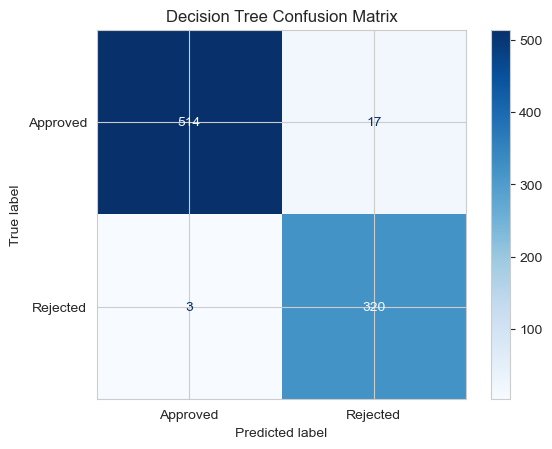

In [27]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le_target.classes_)
disp.plot(cmap='Blues')
plt.title("Decision Tree Confusion Matrix")

plt.savefig("D:/DSML/Loan-Approval-Prediction-Decision-Tree-Random-Forest/images/decision_tree_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

### Decision Tree Visualization

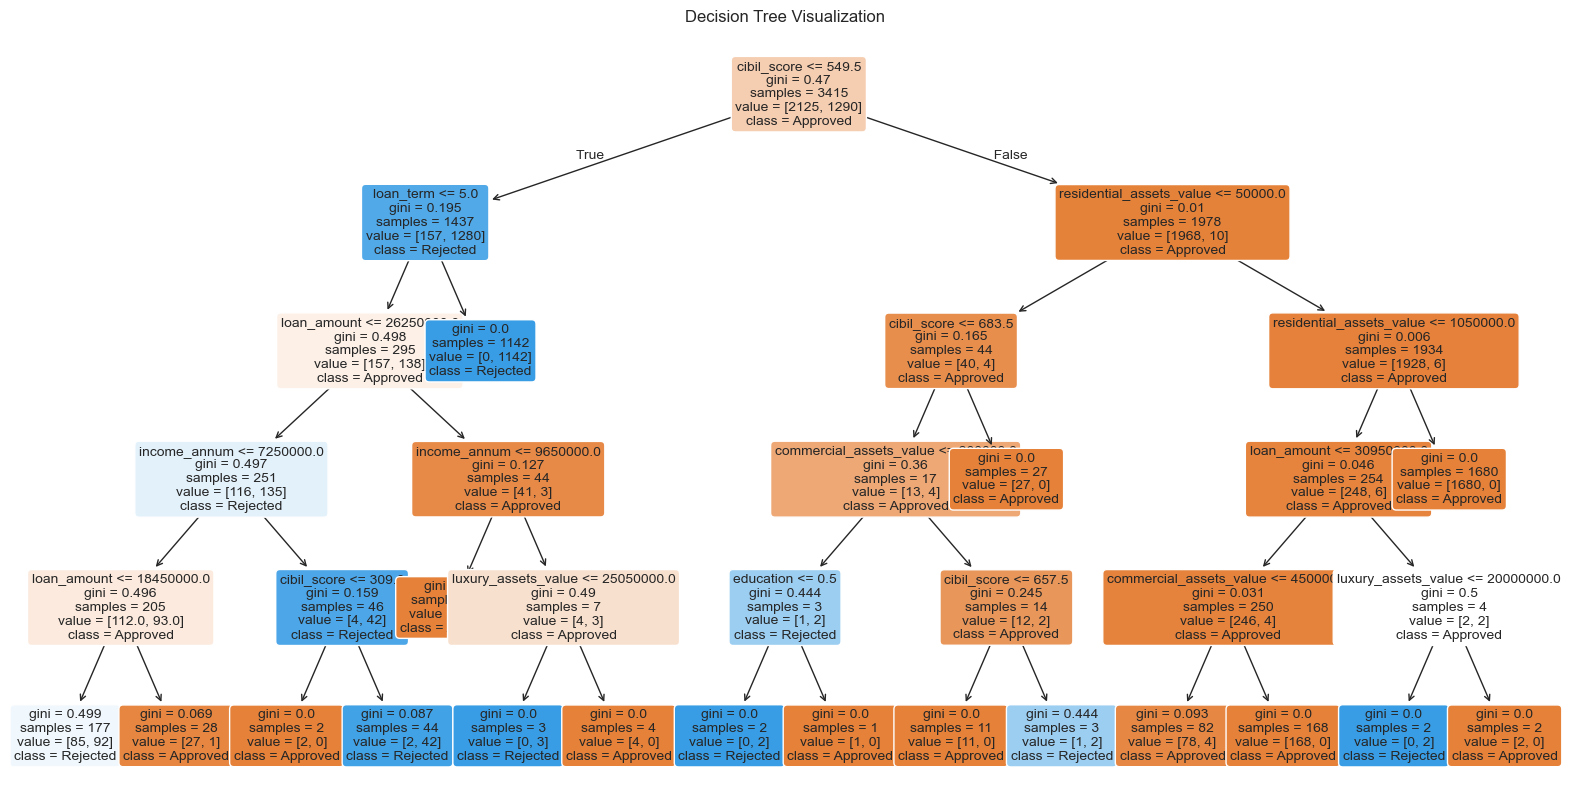

In [28]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=le_target.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization")

plt.savefig("D:/DSML/Loan-Approval-Prediction-Decision-Tree-Random-Forest/images/decision_tree_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Random Forest Model
### Random Forest Classifier
A Random Forest model is trained next. Since it is an ensemble of many decision trees, it usually performs better and is more robust than a single decision tree.

In [29]:
# ==============================
#    Random Forest Model
# ==============================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

Random Forest Accuracy: 0.966


### Random Forest Classification Report

In [30]:
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

Random Forest Classification Report:

              precision    recall  f1-score   support

    Approved       0.98      0.97      0.97       531
    Rejected       0.95      0.97      0.96       323

    accuracy                           0.97       854
   macro avg       0.96      0.97      0.96       854
weighted avg       0.97      0.97      0.97       854



### Random Forest Confusion Matrix

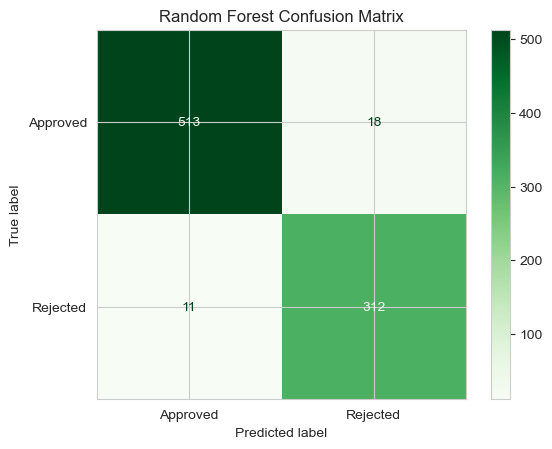

In [31]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le_target.classes_)
disp.plot(cmap='Greens')
plt.title("Random Forest Confusion Matrix")

plt.savefig("D:/DSML/Loan-Approval-Prediction-Decision-Tree-Random-Forest/images/random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Model Comparison
In this section, we compare the performance of Decision Tree and Random Forest models.

In [32]:
# ==============================
#    Model Comparison
# ==============================

comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [dt_accuracy, rf_accuracy]
})

comparison_df

,Model,Accuracy
0,Decision Tree,0.976581
1,Random Forest,0.966042


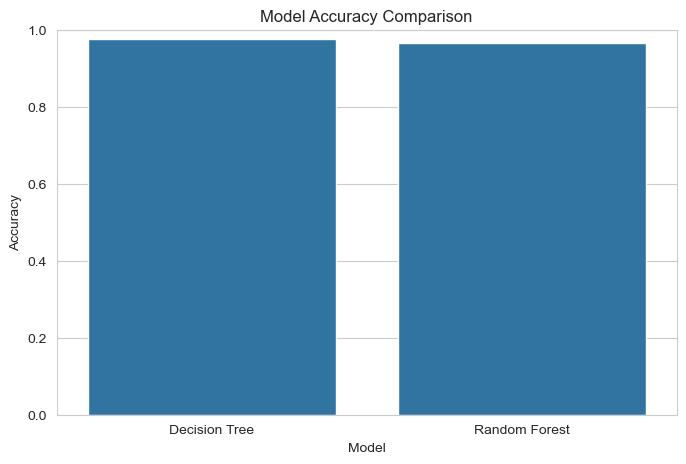

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=comparison_df)
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)

plt.savefig("D:/DSML/Loan-Approval-Prediction-Decision-Tree-Random-Forest/images/model_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
print(comparison_df)

           Model  Accuracy
0  Decision Tree  0.976581
1  Random Forest  0.966042


## 12. Feature Importance Analysis
Feature importance helps identify which variables contribute most to predicting loan approval.

### Decision Tree Feature Importance

In [35]:
dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

dt_importance

,Feature,Importance
6,cibil_score,0.873663
5,loan_term,0.088398
4,loan_amount,0.019762
3,income_annum,0.011994
9,luxury_assets_value,0.003613
8,commercial_assets_value,0.001077
1,education,0.000887
7,residential_assets_value,0.000605
0,no_of_dependents,0.000000
2,self_employed,0.000000


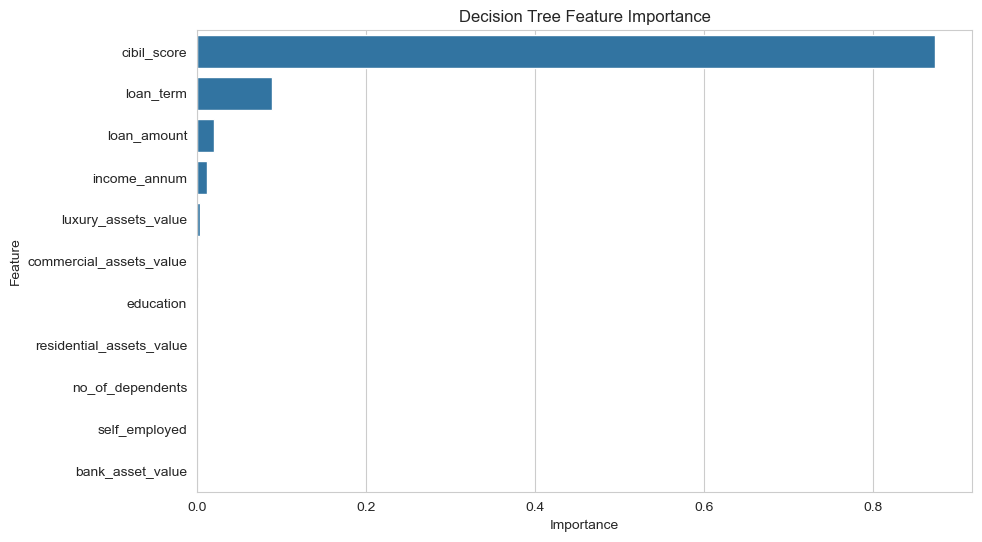

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=dt_importance)
plt.title("Decision Tree Feature Importance")

plt.savefig("D:/DSML/Loan-Approval-Prediction-Decision-Tree-Random-Forest/images/decision_tree_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

### Random Forest Feature Importance

In [37]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

rf_importance

,Feature,Importance
6,cibil_score,0.812605
5,loan_term,0.091944
4,loan_amount,0.020306
8,commercial_assets_value,0.016291
9,luxury_assets_value,0.015343
7,residential_assets_value,0.012976
3,income_annum,0.012164
10,bank_asset_value,0.011824
0,no_of_dependents,0.004426
1,education,0.001502


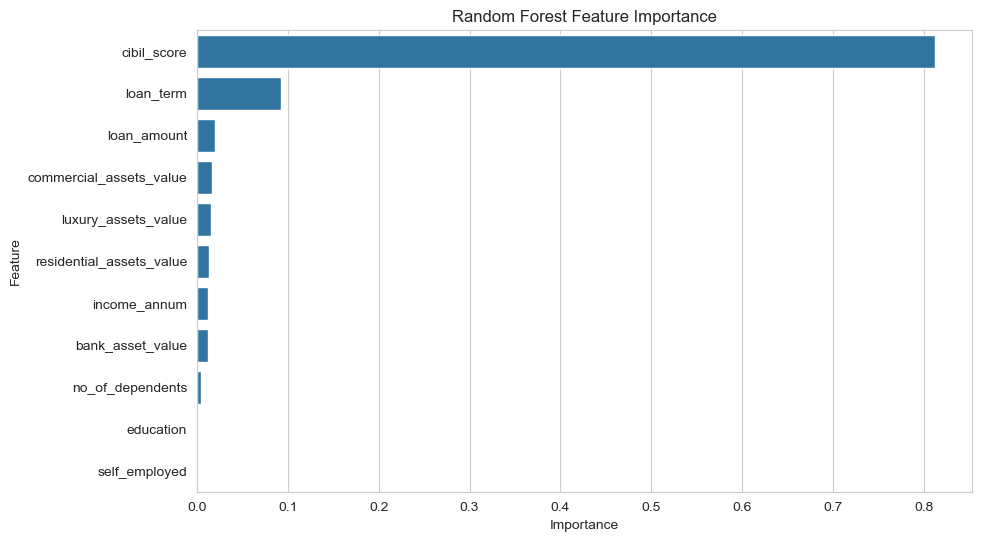

In [38]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance)
plt.title("Random Forest Feature Importance")

plt.savefig("D:/DSML/Loan-Approval-Prediction-Decision-Tree-Random-Forest/images/random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Final Conclusion
In this project, we developed two machine learning classification models to predict loan approval status:

- Decision Tree Classifier
- Random Forest Classifier

### Key Findings
- The dataset was clean and did not contain missing values.
- Categorical variables were encoded for model training.
- Both models were able to classify loan approval status effectively.
- Random Forest generally performs better because it combines multiple decision trees and reduces overfitting.
- Feature importance analysis showed that variables such as **CIBIL score, loan amount, income, and asset values** play important roles in loan approval prediction.

### Overall Result
This project demonstrates how machine learning can assist financial institutions in making faster and more consistent loan approval decisions.

Among the two models, **Random Forest is expected to be the better-performing and more reliable model** for this dataset.